In [2]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import os
from dataclasses import dataclass
import pickle
from matplotlib.colors import LogNorm
from scipy import stats
os.environ['BEARER_TOKEN_FILE'] = f"/tmp/bt_u{os.getuid()}_icarus"
from matplotlib.path import Path
from scipy.interpolate import griddata
from matplotlib.lines import Line2D


In [84]:
def get_array(tree, name, library="np"):
    attempts = 5
    for attempt in range(attempts):
        try:
            arr = tree[name].array(library=library)
            return arr
        except Exception as e:
            print(f"Attempt {attempt + 1} failed: {e}")
            continue
    raise RuntimeError(f"Failed to get array for {name} after {attempts} attempts")

def lsnd_path(x_contour, y_contour):
    """Closed polygon from contour points in log space."""
    pts = np.column_stack([np.log10(x_contour), np.log10(y_contour)])
    pts = np.vstack([pts, pts[0]])  # close it
    codes = [Path.MOVETO] + [Path.LINETO] * (len(pts) - 2) + [Path.CLOSEPOLY]
    return Path(pts, codes)

def points_in_blob(x_contour, y_contour, n, pad=0.15, radius=0.05):
    """Return (theta, mass) arrays for grid points inside the LSND contour.
    pad   : extra decades beyond contour bounds for the candidate grid
    radius: Path buffer — positive value admits points just outside the boundary
    """
    theta_cands = np.logspace(np.log10(x_contour.min()) - pad, np.log10(x_contour.max()) + pad, n)
    mass_cands  = np.logspace(np.log10(y_contour.min()) - pad, np.log10(y_contour.max()) + pad, n)
    TT, MM = np.meshgrid(theta_cands, mass_cands)
    log_pts = np.column_stack([np.log10(TT.ravel()), np.log10(MM.ravel())])
    inside = lsnd_path(x_contour, y_contour).contains_points(log_pts, radius=radius)
    return TT.ravel()[inside], MM.ravel()[inside]

In [213]:
@dataclass
class OscillationPoint:
    mass: float
    theta_ue: float
    theta_ee: float
    probability_ee: np.ndarray
    probability_ue: np.ndarray
    nu_yield: float = None

mb23 = np.loadtxt('/nashome/m/micarrig/sbnd/nueCCNp/medulla/analysis/microboone_2023_appearance.csv', delimiter=',', skiprows=1)
mb25 = np.loadtxt('/nashome/m/micarrig/sbnd/nueCCNp/medulla/analysis/microboone_2025.csv', delimiter=',', skiprows=1)
lsnd_low = np.loadtxt('/nashome/m/micarrig/sbnd/nueCCNp/medulla/analysis/lsnd_99_lower.csv', delimiter=',', skiprows=1)
lsnd_mid = np.loadtxt('/nashome/m/micarrig/sbnd/nueCCNp/medulla/analysis/lsnd_99_mid.csv', delimiter=',', skiprows=1)
lsnd_upper = np.loadtxt('/nashome/m/micarrig/sbnd/nueCCNp/medulla/analysis/lsnd_99_upper.csv', delimiter=',', skiprows=1)
katrin12 = np.loadtxt('/nashome/m/micarrig/sbnd/nueCCNp/medulla/analysis/Katrin_1-2.csv', delimiter=',', skiprows=1)
katrin15 = np.loadtxt('/nashome/m/micarrig/sbnd/nueCCNp/medulla/analysis/Katrin_1-5.csv', delimiter=',', skiprows=1)
sg_low = np.loadtxt('/nashome/m/micarrig/sbnd/nueCCNp/medulla/analysis/galex-sage-low.csv', delimiter=',', skiprows=1)
sg_high = np.loadtxt('/nashome/m/micarrig/sbnd/nueCCNp/medulla/analysis/galex-sage-high.csv', delimiter=',', skiprows=1)
prospect = np.loadtxt('/nashome/m/micarrig/sbnd/nueCCNp/medulla/analysis/prospect-5sigma.csv', delimiter=',', skiprows=1)
x_mb23, y_mb23 = mb23[:, 0], mb23[:, 1]
x_mb25, y_mb25 = mb25[:, 0], mb25[:, 1]
x_lsnd_low, y_lsnd_low = lsnd_low[:, 0], lsnd_low[:, 1]
x_lsnd_mid, y_lsnd_mid = lsnd_mid[:, 0], lsnd_mid[:, 1]
x_lsnd_upper, y_lsnd_upper = lsnd_upper[:, 0], lsnd_upper[:, 1]
x_katrin12, y_katrin12 = katrin12[:, 0], katrin12[:, 1]
x_katrin15, y_katrin15 = katrin15[:, 0], katrin15[:, 1]
x_sg_low, y_sg_low = sg_low[:, 0], sg_low[:, 1]
x_sg_high, y_sg_high = sg_high[:, 0], sg_high[:, 1]
x_prospect, y_prospect = prospect[:, 0], prospect[:, 1]

In [343]:
def get_efficiency(all_, sel_, bins_, range_, title_, logy=False):
    fig, ax = plt.subplots(
    2, 1,
    figsize=(10, 8),
    gridspec_kw={"height_ratios": [3, 1]})
    
    all_count = (all_ >= range_[0]) & (all_ <= range_[1])
    sel_count = (sel_ >= range_[0]) & (sel_ <= range_[1])
    print(f"Total events in range {range_}: {np.sum(all_count)}/{len(all_count)}")
    print(f"Selected events in range {range_}: {np.sum(sel_count)}/{len(sel_count)}")

    ax[0].hist(all_, bins=bins_, range=range_, alpha=0.5, label=f'True Signal: N={np.sum(all_count)}', color='blue')
    ax[0].hist(sel_, bins=bins_, range=range_, alpha=0.5, label=f'Selected Events: N={np.sum(sel_count)}', color='orange')
    ax[0].legend()
    ax[0].set_xlabel(rf'{title_}')
    ax[0].set_ylabel('Counts')
    if logy:
        ax[0].set_yscale('log')
        
    true_hist = np.histogram(all_, bins=bins_, range=range_)
    selected_hist = np.histogram(sel_, bins=bins_, range=range_)

    if isinstance(bins, list):
        x_edges = np.array(bins[1:])
    else:
        x_edges = np.linspace(range_[0], range_[1], bins_ + 1)[:-1]
    ax[1].plot(x_edges, selected_hist[0] / true_hist[0], drawstyle='steps-post', color='green')
    ax[1].set_xlabel(rf'{title_}')
    ax[1].set_ylabel('Efficiency')

    eff = selected_hist[0] / true_hist[0]
    eff = np.nan_to_num(eff, nan=0.0, posinf=0.0, neginf=0.0)
    return eff, selected_hist

def make_grid(muon_arr, ele_arr, true_numu_e, true_nue_e, L, bins, b_range, roi, theta_ee=None, theta_mue=None, left_of=None):
    lsnd_grid = []

    if theta_ee is None and theta_mue is None:
        raise ValueError("At least one of theta_ee or theta_mue must be provided.")

    if left_of is not None:
        log_cx = np.log10(left_of.x)
        log_cy = np.log10(left_of.y)
        sort_idx = np.argsort(log_cy)
        log_cx_sorted = log_cx[sort_idx]
        log_cy_sorted = log_cy[sort_idx]

    grid_regions = [(r.x, r.y, r.name, r.grid_points) for r in roi]

    for blob_x, blob_y, label, n in grid_regions:
        theta_vals, mass_vals = points_in_blob(blob_x, blob_y, n)
        if left_of is not None:
            log_m = np.log10(mass_vals)
            in_range = (log_m >= log_cy_sorted.min()) & (log_m <= log_cy_sorted.max())
            x_at_mass = np.interp(log_m, log_cy_sorted, log_cx_sorted)
            mask = ~in_range | (np.log10(theta_vals) < x_at_mass)
            theta_vals = theta_vals[mask]
            mass_vals = mass_vals[mask]
        print(f"  {label}: {len(theta_vals)} points selected from {n}x{n} candidates")
        for t, m in zip(theta_vals, mass_vals):
            if theta_ee is not None:
                cur_theta_ee = theta_ee
                cur_theta_mue = t
            else:
                cur_theta_ee = t
                cur_theta_mue = theta_mue
            p_mu_e = P_mu_e(cur_theta_mue, m, L, true_numu_e)
            p_e_e = P_e_e(cur_theta_ee, m, L, true_nue_e)
            h_mu_e = np.histogram(muon_arr, bins=bins, range=b_range, weights=p_mu_e)
            h_e_e = np.histogram(ele_arr, bins=bins, range=b_range, weights=p_e_e)
            lsnd_grid.append(OscillationPoint(mass=m, theta_ue=cur_theta_mue, theta_ee=cur_theta_ee, probability_ue=h_mu_e[0], probability_ee=h_e_e[0]))
    return lsnd_grid

@dataclass
class dataCurves:
    x: np.ndarray
    y: np.ndarray
    color: str
    style: str
    type: str
    name: str
    grid_points: int = None
    label: str = None

def _scanning_theta_ee(grid):
    vals = np.array([p.theta_ee for p in grid])
    return bool(np.any(vals != vals[0]))

def plot_phase_space(grid, eff=None, sel_hist=None, curves=None, err_sensitivity=False, points_only=False):
    mass_pts = [p.mass for p in grid]
    scanning = _scanning_theta_ee(grid)
    theta_pts = [p.theta_ee for p in grid] if scanning else [p.theta_ue for p in grid]
    x_label = r'$\sin^2(2\theta_{ee})$' if scanning else r'$\sin^2(2\theta_{ue})$'

    if points_only:
        fig, ax = plt.subplots(figsize=(10, 6))
        title = (rf'Grid Points ($\sin^2(2\theta_{{ue}}) = {grid[0].theta_ue}$)' if scanning
                 else rf'Grid Points ($\sin^2(2\theta_{{ee}}) = {grid[0].theta_ee}$)')

        if curves:
            for c in curves:
                kw = dict(color=c.color, alpha=0.4) if c.type == 'fill' else dict(color=c.color, linestyle=c.style)
                if c.label is not None:
                    kw['label'] = c.label
                (ax.fill if c.type == 'fill' else ax.plot)(c.x, c.y, **kw)

        ax.scatter(theta_pts, mass_pts, alpha=0.9, color='black', s=40)
        ax.set_xscale('log'); ax.set_yscale('log')
        ax.set_ylabel(r'$\Delta m_{41}^2\ (eV^2)$')
        ax.set_xlabel(x_label)
        ax.set_title(title)
        if curves:
            ax.legend()
        return fig

    fig, ax = plt.subplots(1, 2, figsize=(20, 6))

    if scanning:
        single_yield = [np.sum(pt.probability_ee * eff) / np.sum(sel_hist[0]) for pt in grid]
        total_yield  = [(np.sum(pt.probability_ue * eff) + np.sum(pt.probability_ee * eff)) / np.sum(sel_hist[0]) for pt in grid]
        single_label  = r'$\nu_e$ Survival Fraction'
        single_title  = rf'$\nu_e$ Disappearance ($\sin^2(2\theta_{{ue}}) = {grid[0].theta_ue}$)'
        total_title   = rf'Total Oscillation Yield ($\sin^2(2\theta_{{ue}}) = {grid[0].theta_ue}$)'
        print(f"Plotting for fixed theta_ue = {grid[0].theta_ue}")
    else:
        single_yield = [(np.sum(pt.probability_ue * eff) + np.sum(sel_hist[0])) / np.sum(sel_hist[0]) for pt in grid]
        total_yield  = [(np.sum(pt.probability_ue * eff) + np.sum(pt.probability_ee * eff)) / np.sum(sel_hist[0]) for pt in grid]
        single_label  = r'Ratio of $\nu_e$ Events to Nominal'
        single_title  = rf'$\nu_e$ Appearance Only ($\sin^2(2\theta_{{ee}}) = {grid[0].theta_ee}$)'
        total_title   = rf'Total Oscillation Yield ($\sin^2(2\theta_{{ee}}) = {grid[0].theta_ee}$)'
        print(f"Plotting for fixed theta_ee = {grid[0].theta_ee}")

    for c in curves:
        for a in ax:
            kw = dict(color=c.color, alpha=0.4) if c.type == 'fill' else dict(color=c.color, linestyle=c.style)
            if c.label is not None:
                kw['label'] = c.label
            (a.fill if c.type == 'fill' else a.plot)(c.x, c.y, **kw)

    s1 = ax[0].scatter(theta_pts, mass_pts, alpha=0.9, c=single_yield, cmap='viridis', s=100)
    ax[0].set_xscale('log'); ax[0].set_yscale('log')
    fig.colorbar(s1, ax=ax[0], label=single_label)
    ax[0].set_ylabel(r'$\Delta m_{41}^2\ (eV^2)$')
    ax[0].set_xlabel(x_label)
    ax[0].set_title(single_title)
    ax[0].legend()

    if err_sensitivity:
        log_x = np.log10(theta_pts)
        log_y = np.log10(mass_pts)
        xi = np.linspace(log_x.min(), log_x.max(), 300)
        yi = np.linspace(log_y.min(), log_y.max(), 300)
        Xi, Yi = np.meshgrid(xi, yi)
        Zi = griddata((log_x, log_y), np.array(single_yield), (Xi, Yi), method='linear')
        threshold = 0.87 if scanning else 1.13
        ax[0].contour(10**Xi, 10**Yi, Zi, levels=[threshold], colors=['black'], linewidths=2, linestyles='--')
        label = '13% disappearance threshold' if scanning else '13% systematic threshold'
        ax[0].legend(handles=[*ax[0].get_legend().legend_handles,
                               Line2D([0], [0], color='black', lw=2, ls='--', label=label)])

    s2 = ax[1].scatter(theta_pts, mass_pts, alpha=0.9, c=total_yield, cmap='viridis', s=100)
    ax[1].set_xscale('log'); ax[1].set_yscale('log')
    fig.colorbar(s2, ax=ax[1], label=r'Ratio of $\nu_e$ Events to Nominal')
    ax[1].set_ylabel(r'$\Delta m_{41}^2\ (eV^2)$')
    ax[1].set_xlabel(x_label)
    ax[1].set_title(total_title)
    ax[1].legend()

    if err_sensitivity:
        Zi = griddata((log_x, log_y), np.array(total_yield), (Xi, Yi), method='linear')
        ax[1].contour(10**Xi, 10**Yi, Zi, levels=[1.13], colors=['black'], linewidths=2, linestyles='--')
        ax[1].legend(handles=[*ax[1].get_legend().legend_handles,
                               Line2D([0], [0], color='black', lw=2, ls='--', label='13% systematic threshold')])

def plot_variable_osc(grid, eff, sel_hist, title, uncertainty=0.13, scale=None):
    fig, ax = plt.subplots(
        2, 1,
        figsize=(16, 12),
        gridspec_kw={"height_ratios": [3, 1]})

    pot_scale = scale if scale is not None else 1.0
    nominal = pot_scale * sel_hist[0].astype(float)
    # safe denominator avoids divide-by-zero warnings inside np.where
    safe_nom = np.where(nominal > 0, nominal, 1.0)
    ratio_mask = (nominal > 0) & (eff > 0)
    safe_denom = np.where(ratio_mask, nominal, 1.0)

    scanning = _scanning_theta_ee(grid)
    if scanning:
        plot_title = rf'Oscillated Spectrum ($\sin^2(2\theta_{{ue}}) = {grid[0].theta_ue}$)'
    else:
        plot_title = rf'Oscillated Spectrum ($\sin^2(2\theta_{{ee}}) = {grid[0].theta_ee}$)'

    err = uncertainty
    x_step = np.repeat(sel_hist[1], 2)[1:-1]
    nom_step = np.repeat(nominal, 2)

    chi2_vals = []
    for ipt, pt in enumerate(grid):
        osc = pot_scale * ((pt.probability_ue * eff) + (pt.probability_ee * eff))
        if ipt == 0:
            ax[0].plot(x_step, np.repeat(osc, 2), alpha=0.3, color='red', label='Oscillated Events')
        else:
            ax[0].plot(x_step, np.repeat(osc, 2), alpha=0.3, color='red')
        chi2_vals.append(np.sum((osc - nominal)**2 / ((uncertainty * nominal) + 1e-9)**2))

    ax[0].plot(x_step, nom_step, alpha=1, label='Nominal', color='blue', linewidth=2)
    ax[0].fill_between(x_step, nom_step * (1 - err), nom_step * (1 + err),
                       facecolor='none', edgecolor='blue', hatch='///', alpha=0.5,
                       label=f'{int(err * 100)}% uncertainty', zorder=5)
    ax[0].set_xlim(sel_hist[1][0], sel_hist[1][-1])
    ax[0].set_xlabel(rf'{title}')
    ax[0].set_ylabel('Frequency')
    ax[0].set_title(plot_title)
    ax[0].legend()
    for lh in ax[0].get_legend().legend_handles:
        lh.set_alpha(1); lh.set_linewidth(2)

    all_ratios = np.array([
        np.where(nominal > 0,
                 pot_scale * ((pt.probability_ue * eff) + (pt.probability_ee * eff)) / safe_nom,
                 np.nan)
        for pt in grid
    ])
    finite_ratios = all_ratios[np.isfinite(all_ratios)]
    if finite_ratios.size:
        ax[1].set_ylim(min(np.min(finite_ratios), 1 - uncertainty - 0.05),
                       max(np.max(finite_ratios), 1 + uncertainty + 0.05))

    x_idx = np.arange(len(nominal))
    for pt in grid:
        osc_total = pot_scale * ((pt.probability_ue * eff) + (pt.probability_ee * eff))
        ratio_raw = np.where(ratio_mask, osc_total / safe_denom, np.nan)
        finite = np.isfinite(ratio_raw)
        ratio = np.interp(x_idx, x_idx[finite], ratio_raw[finite]) if finite.sum() > 1 else np.ones_like(ratio_raw)
        ax[1].plot(x_step, np.repeat(ratio, 2), alpha=0.3, color='red')

    ax[1].set_xlim(sel_hist[1][0], sel_hist[1][-1])
    ax[1].axhline(1.0, color='blue', linewidth=1.5)
    ax[1].axhline(1 - uncertainty, color='blue', linewidth=1.5, linestyle='--',
                  label=f'{int((1 - uncertainty) * 100)}% / {int((1 + uncertainty) * 100)}%')
    ax[1].axhline(1 + uncertainty, color='blue', linewidth=1.5, linestyle='--')
    ax[1].set_xlabel(rf'{title}')
    ax[1].set_ylabel('Ratio to Nominal')
    ax[1].legend(fontsize=8)

    return fig

In [6]:
fin = uproot.open("/exp/icarus/data/users/micarrig/merged_v24.root:events/NuMIFull/selected")
fall = uproot.open("/exp/icarus/data/users/micarrig/merged_v24.root:events/NuMIFull/all")
f_true= uproot.open("/exp/icarus/data/users/micarrig/merged_v24.root:events/NuMIFull/true_signal")


In [46]:
limit_curves = []
limit_curves.append(dataCurves(x_mb23, y_mb23, 'red', '-', 'line', 'mb23', 0, 'MicroBooNE Result (2023)'))
limit_curves.append(dataCurves(x_mb25, y_mb25, 'orange', '-','line', 'mb25', 0, 'MicroBooNE Result (2025)'))
limit_curves.append(dataCurves(x_lsnd_low, y_lsnd_low, 'gray', '-', 'fill', 'lsnd_low', 30, 'LSND 99% CL'))
limit_curves.append(dataCurves(x_lsnd_mid, y_lsnd_mid, 'gray', '-', 'fill', 'lsnd_mid', 10))
limit_curves.append(dataCurves(x_lsnd_upper, y_lsnd_upper, 'gray', '-', 'fill', 'lsnd_upper', 15))

In [8]:
sin2_2theta_ue = 0.004
sin2_2theta_ee = 0.6
delta_m41 = 3.0 # ev

L = 0.795 # km

In [10]:
def P_e_e(sin2_2theta_ee, delta_m41, L, E):
    """Calculate the oscillation probability for electron to electron neutrino oscillation."""
    val = 1 - sin2_2theta_ee * np.sin( 1.27 * delta_m41 * L / E)**2
    return val

def P_mu_e(sin2_2theta_ue, delta_m41, L, E):
    """Calculate the oscillation probability for muon to electron neutrino oscillation."""
    val = sin2_2theta_ue * np.sin( 1.27 * delta_m41 * L / E)**2
    return val

def P_mu_mu(sin2_2theta_uu, delta_m41, L, E):
    """Calculate the oscillation probability for muon to muon neutrino oscillation."""
    val = 1 - sin2_2theta_uu * np.sin( 1.27 * delta_m41 * L / E)**2
    return val

In [11]:
true_category = get_array(fin, 'true_category')
mask = (true_category == 0)

#test adding energy selection 
reco_energy = get_array(fin, 'reco_leading_electron_ke')
true_energy = get_array(fin, 'true_leading_electron_ke')

# mask = mask & (reco_energy > 500) & (true_energy > 500)

In [12]:
nu_e = get_array(fin, 'true_neutrino_energy')
nu_e = nu_e[mask]

## Get The Efficiency for Selecting True Electron Neutrinos

In [13]:
true_sig_category = get_array(fall, 'true_category', library="np")
true_sig_mask = (true_sig_category < 2) # get all electron neutrinos w/o any selections
true_sig_nu_e = get_array(fall, 'true_neutrino_energy', library="np")
true_sig_nu_e = true_sig_nu_e[true_sig_mask]

In [14]:
np.sum(true_sig_mask), len(nu_e), len(fin['true_neutrino_energy'].array(library="np"))

(39164, 9637, 11795)

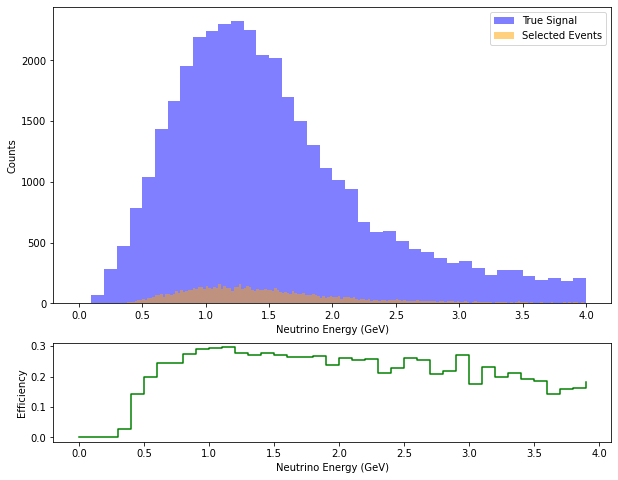

In [15]:
fig, ax = plt.subplots(
    2, 1,
    figsize=(10, 8),
    gridspec_kw={"height_ratios": [3, 1]})
    
ax[0].hist(true_sig_nu_e, bins=40, range=(0, 4), alpha=0.5, label='True Signal', color='blue')
ax[0].hist(nu_e, bins=200, range=(0, 4), alpha=0.5, label='Selected Events', color='orange')
ax[0].legend()
ax[0].set_xlabel('Neutrino Energy (GeV)')
ax[0].set_ylabel('Counts')

true_hist = np.histogram(true_sig_nu_e, bins=40, range=(0, 4))[0]
selected_hist = np.histogram(nu_e, bins=40, range=(0, 4))[0]
x_edges = np.linspace(0, 4, 41)
ax[1].plot(x_edges[:-1], selected_hist / true_hist, drawstyle='steps-post', color='green')
ax[1].set_xlabel('Neutrino Energy (GeV)')
ax[1].set_ylabel('Efficiency')

eff = selected_hist / true_hist
eff = np.nan_to_num(eff, nan=0.0, posinf=0.0, neginf=0.0)
plt.show()

## Get the total number of muon neutrinos

In [16]:
all_true_category = get_array(fall, 'true_category', library="np")
muon_true_mask = (all_true_category == 2) #note this is not counting NC events or cosmics

all_nu_e = get_array(fall, 'true_neutrino_energy', library="np")
muon_nu_e = all_nu_e[muon_true_mask]

In [17]:
total_nue = np.sum((all_true_category < 2))
signal_nue = np.sum((all_true_category == 0))
total_numuon = np.sum(all_true_category == 2)

ratio = total_nue / total_numuon
print(f"Total nue: {total_nue}, Total numuon: {total_numuon}, Ratio: {ratio}")
print(f"Total nue: {total_nue}, Signal nue: {signal_nue}, Ratio: {signal_nue / total_nue}")

Total nue: 39164, Total numuon: 473949, Ratio: 0.08263336350535606
Total nue: 39164, Signal nue: 18986, Ratio: 0.48478194260034724


## Calculate the electron appearance

In [18]:
nu_e_app = P_mu_e(sin2_2theta_ue, delta_m41, L, muon_nu_e) #Probability to oscillate from muon to electron neutrino
nu_e_dis = P_e_e(sin2_2theta_ee, delta_m41, L, true_sig_nu_e) #Probability to oscillate from electron to electron neutrino

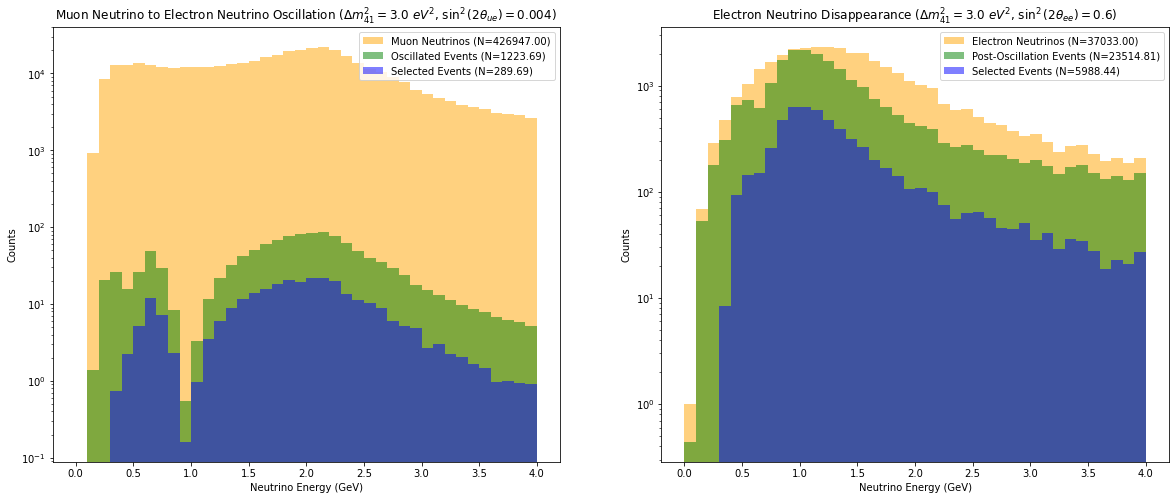

In [19]:
fig, ax = plt.subplots(
    1, 2,
    figsize=(20, 8))

mu_e_hist, edges = np.histogram(muon_nu_e, bins=40, range=(0, 4))
e_e_hist, edges = np.histogram(true_sig_nu_e, bins=40, range=(0, 4))

appearance_hist, _ = np.histogram(muon_nu_e, bins=40, range=(0, 4), weights=nu_e_app)
disappearance_hist, _ = np.histogram(true_sig_nu_e, bins=40, range=(0, 4), weights=nu_e_dis)

sel_hist_mu = appearance_hist * eff
sel_hist_e = disappearance_hist * eff

ax[0].hist(edges[:-1], bins=edges, weights=mu_e_hist, alpha=0.5, label=f'Muon Neutrinos (N={np.sum(mu_e_hist):.2f})', color='orange')
ax[0].hist(edges[:-1], bins=edges, weights=appearance_hist, alpha=0.5, label=f'Oscillated Events (N={np.sum(appearance_hist):.2f})', color='green')
ax[0].hist(edges[:-1], bins=edges, weights=sel_hist_mu, alpha=0.5, label=f'Selected Events (N={np.sum(sel_hist_mu):.2f})', color='blue')
ax[0].legend()
ax[0].set_xlabel('Neutrino Energy (GeV)')
ax[0].set_ylabel('Counts')
ax[0].set_title(rf'Muon Neutrino to Electron Neutrino Oscillation ($\Delta m^2_{{41}} = {delta_m41}\ eV^2$, $\sin^2(2\theta_{{ue}}) = {sin2_2theta_ue}$)')
ax[0].set_yscale('log')

ax[1].hist(edges[:-1], bins=edges, weights=e_e_hist, alpha=0.5, label=f'Electron Neutrinos (N={np.sum(e_e_hist):.2f})', color='orange')
ax[1].hist(edges[:-1], bins=edges, weights=disappearance_hist, alpha=0.5, label=f'Post-Oscillation Events (N={np.sum(disappearance_hist):.2f})', color='green')
ax[1].hist(edges[:-1], bins=edges, weights=sel_hist_e, alpha=0.5, label=f'Selected Events (N={np.sum(sel_hist_e):.2f})', color='blue')
ax[1].legend()
ax[1].set_xlabel('Neutrino Energy (GeV)')
ax[1].set_ylabel('Counts')
ax[1].set_title(
    rf'Electron Neutrino Disappearance ($\Delta m^2_{{41}} = {delta_m41}\ eV^2$, '
    rf'$\sin^2(2\theta_{{ee}}) = {sin2_2theta_ee}$)'
)
ax[1].set_yscale('log')

/tmp/ipykernel_6608/1316667862.py:28: RuntimeWarning: invalid value encountered in divide
  ax[1].scatter(edges[:-1], osc_mu2e / nom, color='red', label=rf'$\nu_\mu \to \nu_e$', s=10)
/tmp/ipykernel_6608/1316667862.py:29: RuntimeWarning: invalid value encountered in divide
  ax[1].scatter(edges[:-1], osc_e2e / nom, color='green', label=rf'$\nu_e \to \nu_e$', s=10)
/tmp/ipykernel_6608/1316667862.py:30: RuntimeWarning: invalid value encountered in divide
  ax[1].scatter(edges[:-1], osc_full / nom, color='purple', label=rf'$\nu_\mu \to \nu_e + \nu_e \to \nu_e$', s=10)


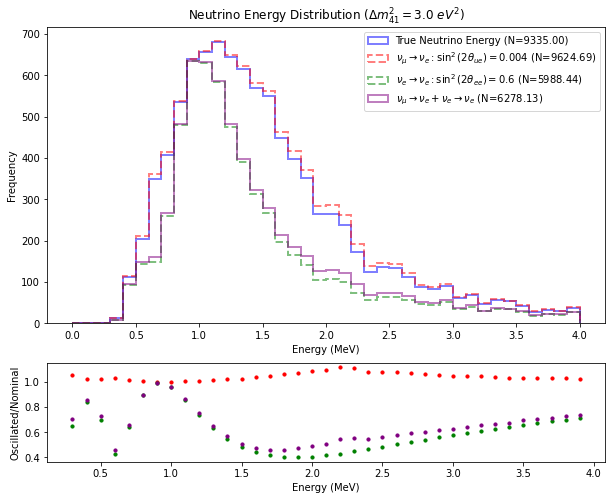

In [20]:
fig, ax = plt.subplots(
    2, 1,
    figsize=(10, 8),
    gridspec_kw={"height_ratios": [3, 1]})

appearance_hist, edges = np.histogram(muon_nu_e, bins=40, range=(0, 4), weights=nu_e_app)
disappearance_hist, edges = np.histogram(true_sig_nu_e, bins=40, range=(0, 4), weights=nu_e_dis)

eff = np.nan_to_num(eff, nan=0.0) #replace NaN values with 0
appearance_hist = appearance_hist * eff #multiply by efficiency to get the expected number of events after oscillation
disappearance_hist = disappearance_hist * eff #multiply by efficiency to get the expected number of events after oscillation

nom, edges = np.histogram(nu_e, bins=40, range=(0, 4), weights=np.ones_like(nu_e))

osc_mu2e = appearance_hist + nom
osc_e2e = disappearance_hist
osc_full = appearance_hist + disappearance_hist

ax[0].hist(edges[:-1], bins = edges, weights=nom, alpha=0.5, label=f'True Neutrino Energy (N={np.sum(nom):.2f})', histtype='step', color='blue', linewidth=2)
ax[0].hist(edges[:-1], bins = edges, weights=osc_mu2e, alpha=0.5, label=rf'$\nu_\mu \to \nu_e: \sin^2(2\theta_{{ue}}) = {sin2_2theta_ue}$ (N={np.sum(osc_mu2e):.2f})', histtype='step', color='red', linewidth=2, linestyle='dashed')
ax[0].hist(edges[:-1], bins = edges, weights=osc_e2e, alpha=0.5, label=rf'$\nu_e \to \nu_e: \sin^2(2\theta_{{ee}}) = {sin2_2theta_ee}$ (N={np.sum(osc_e2e):.2f})', histtype='step', color='green', linewidth=2, linestyle='dashed')
ax[0].hist(edges[:-1], bins = edges, weights=osc_full, alpha=0.5, label=rf'$\nu_\mu \to \nu_e + \nu_e \to \nu_e$ (N={np.sum(osc_full):.2f})', histtype='step', color='purple', linewidth=2)
ax[0].set_xlabel('Energy (MeV)')
ax[0].set_ylabel('Frequency')
ax[0].set_title(rf'Neutrino Energy Distribution ($\Delta m^2_{{41}} = {delta_m41}\ eV^2$)')
ax[0].legend()

ax[1].scatter(edges[:-1], osc_mu2e / nom, color='red', label=rf'$\nu_\mu \to \nu_e$', s=10)
ax[1].scatter(edges[:-1], osc_e2e / nom, color='green', label=rf'$\nu_e \to \nu_e$', s=10)
ax[1].scatter(edges[:-1], osc_full / nom, color='purple', label=rf'$\nu_\mu \to \nu_e + \nu_e \to \nu_e$', s=10)
ax[1].set_xlabel('Energy (MeV)')
ax[1].set_ylabel('Oscillated/Nominal')

plt.show()

# Appearance and Disappearance Study

### Choose a few theta_ee values to test against

0.2 - 0.6

In [39]:
theta_ee = 0.6

lsnd_grid = []
for blob_x, blob_y, label, n in [
    (x_lsnd_low,   y_lsnd_low,   "low",   30),
    (x_lsnd_mid,   y_lsnd_mid,   "mid",   10),
    (x_lsnd_upper, y_lsnd_upper, "upper", 15),
]:
    theta_vals, mass_vals = points_in_blob(blob_x, blob_y, n)
    print(f"  {label}: {len(theta_vals)} points selected from {n}x{n} candidates")
    for t, m in zip(theta_vals, mass_vals):
        p_mu_e = P_mu_e(t, m, L, muon_nu_e)
        p_e_e = P_e_e(theta_ee, m, L, true_sig_nu_e)
        h_mu_e = np.histogram(muon_nu_e, bins=40, range=(0, 4), weights=p_mu_e)
        h_e_e = np.histogram(true_sig_nu_e, bins=40, range=(0, 4), weights=p_e_e)
        lsnd_grid.append(OscillationPoint(mass=m, theta_ue=t, theta_ee=theta_ee, probability_ue=h_mu_e[0], probability_ee=h_e_e[0]))

print(f"\nlsnd_grid: {len(lsnd_grid)} points total")

  low: 151 points selected from 30x30 candidates
  mid: 14 points selected from 10x10 candidates
  upper: 91 points selected from 15x15 candidates

lsnd_grid: 256 points total


/tmp/ipykernel_3779/1654509058.py:15: UserWarning: Adding colorbar to a different Figure <Figure size 1440x432 with 3 Axes> than <Figure size 1440x1440 with 4 Axes> which fig.colorbar is called on.
  fig.colorbar(s1, ax=ax[0], label=r'Ratio of $\nu_e$ Events to Nominal')
/tmp/ipykernel_3779/1654509058.py:32: UserWarning: Adding colorbar to a different Figure <Figure size 1440x432 with 4 Axes> than <Figure size 1440x1440 with 4 Axes> which fig.colorbar is called on.
  fig.colorbar(s1, ax=ax[1], label=r'Ratio of $\nu_e$ Events to Nominal')


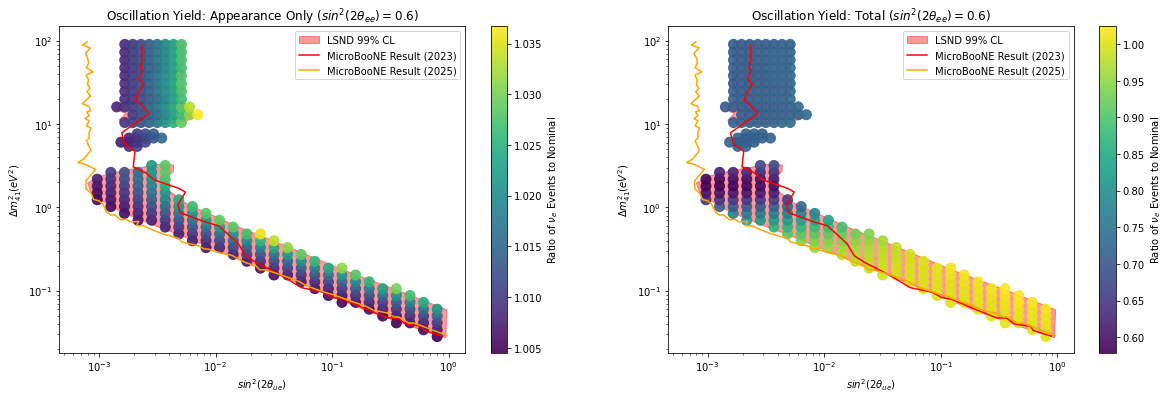

In [40]:
fix, ax = plt.subplots(1, 2, figsize=(20, 6))

nom = np.histogram(nu_e, bins=40, range=(0, 4))

appearance_yield = [ (np.sum((pt.probability_ue * eff)) + np.sum(nom[0])) / np.sum(nom[0]) for pt in lsnd_grid]
total_yield = [ (np.sum((pt.probability_ue * eff)) + np.sum((pt.probability_ee * eff))) / np.sum(nom[0]) for pt in lsnd_grid]

ax[0].fill(x_lsnd_low, y_lsnd_low, color='red', label='LSND 99% CL', alpha=0.4)
ax[0].fill(x_lsnd_mid, y_lsnd_mid, color='red', alpha=0.4)
ax[0].fill(x_lsnd_upper, y_lsnd_upper, color='red', alpha=0.4)

s1 = ax[0].scatter([p.theta_ue for p in lsnd_grid], [p.mass for p in lsnd_grid], alpha = 0.9, c=appearance_yield, cmap='viridis', s=100)
ax[0].set_xscale('log')
ax[0].set_yscale('log')
fig.colorbar(s1, ax=ax[0], label=r'Ratio of $\nu_e$ Events to Nominal')
ax[0].set_ylabel(r'$\Delta m_{41}^2 (eV^2)$')
ax[0].set_xlabel(r'$sin^2(2\theta_{ue})$')
ax[0].set_title(rf'Oscillation Yield: Appearance Only ($sin^2(2\theta_{{ee}}) = {theta_ee}$)')

ax[0].plot(x_mb23, y_mb23, color='red', label='MicroBooNE Result (2023)',linestyle='-')
ax[0].plot(x_mb25, y_mb25, color='orange', label='MicroBooNE Result (2025)',linestyle='-')

ax[0].legend()

ax[1].fill(x_lsnd_low, y_lsnd_low, color='red', label='LSND 99% CL', alpha=0.4)
ax[1].fill(x_lsnd_mid, y_lsnd_mid, color='red', alpha=0.4)
ax[1].fill(x_lsnd_upper, y_lsnd_upper, color='red', alpha=0.4)

s1 = ax[1].scatter([p.theta_ue for p in lsnd_grid], [p.mass for p in lsnd_grid], alpha = 0.9, c=total_yield, cmap='viridis', s=100)
ax[1].set_xscale('log')
ax[1].set_yscale('log')
fig.colorbar(s1, ax=ax[1], label=r'Ratio of $\nu_e$ Events to Nominal')
ax[1].set_ylabel(r'$\Delta m_{41}^2 (eV^2)$')
ax[1].set_xlabel(r'$sin^2(2\theta_{ue})$')
ax[1].set_title(rf'Oscillation Yield: Total ($sin^2(2\theta_{{ee}}) = {theta_ee}$)')

ax[1].plot(x_mb23, y_mb23, color='red', label='MicroBooNE Result (2023)',linestyle='-')
ax[1].plot(x_mb25, y_mb25, color='orange', label='MicroBooNE Result (2025)',linestyle='-')

ax[1].legend()

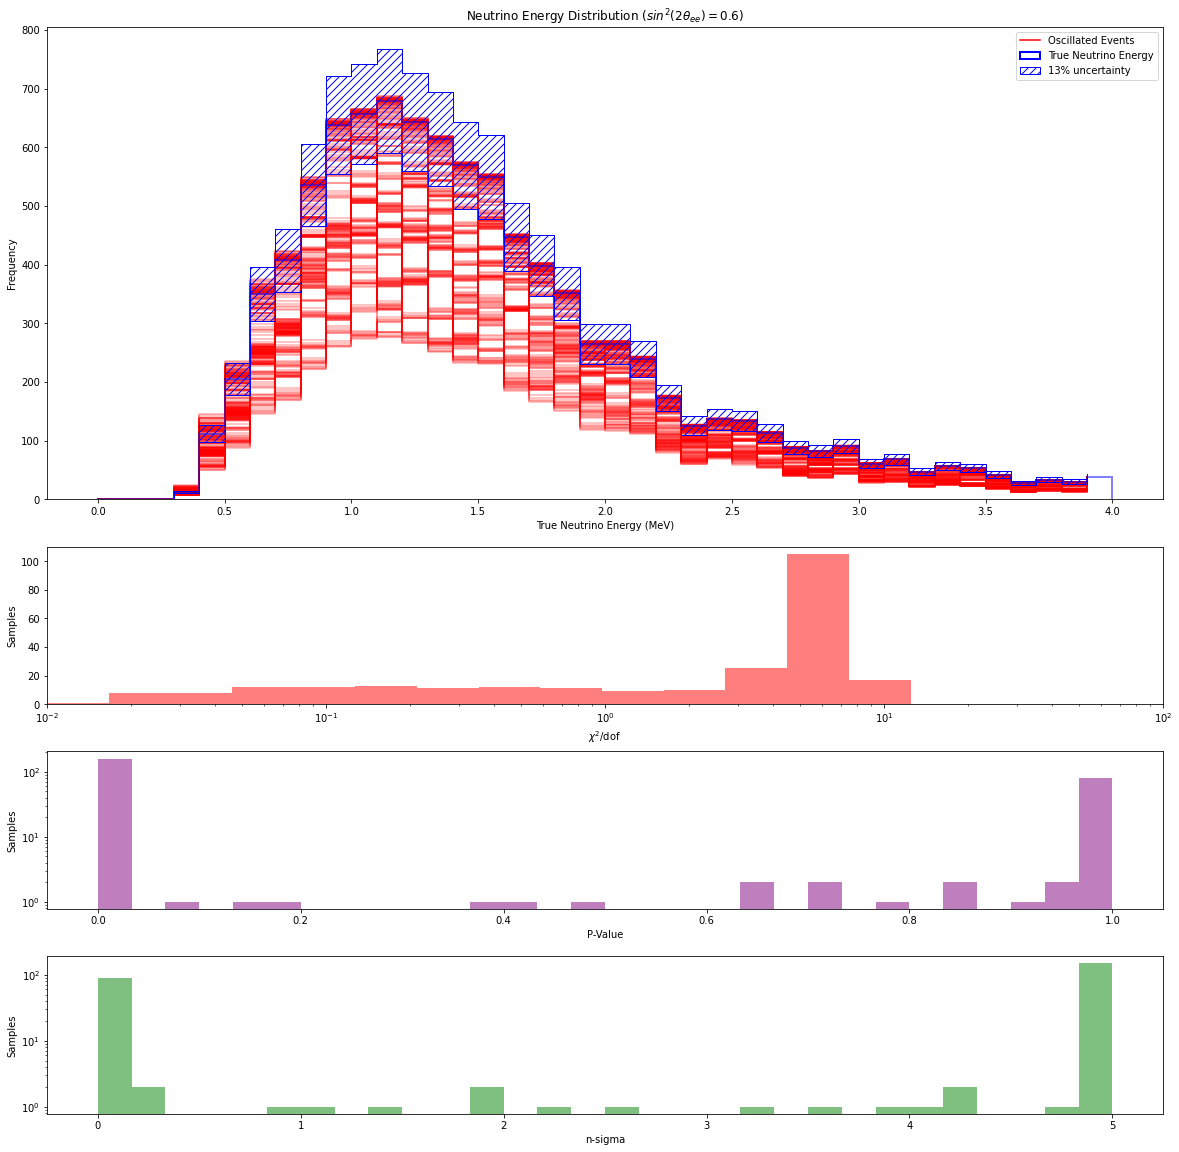

In [41]:
# theta_ee = 0.
# for pt in lsnd_grid:
#     p_ee = P_e_e(theta_ee, pt.mass, L, true_sig_nu_e)
#     h_e_e = np.histogram(true_sig_nu_e, bins=40, range=(0, 4), weights=p_ee)
#     pt.probability_ee = h_e_e[0]

fig, ax = plt.subplots(
    4, 1,
    figsize=(20, 20),
    gridspec_kw={"height_ratios": [3, 1, 1, 1]})

nom = np.histogram(nu_e, bins=40, range=(0, 4))

chi2_vals = []
color = 'red'
for ipt, pt in enumerate(lsnd_grid):
    #if ipt > 5: break
    if ipt == 0:
        ax[0].step(nom[1][:-1], (pt.probability_ue * eff) + (pt.probability_ee * eff), where='post', alpha=0.3, color=color, label='Oscillated Events')
    else:
        ax[0].step(nom[1][:-1], (pt.probability_ue * eff) + (pt.probability_ee * eff), where='post', alpha=0.3, color=color)
    chi2_ = np.sum(((pt.probability_ue * eff) + (pt.probability_ee * eff) - nom[0])**2 / ((0.13 * nom[0]) + 1e-9)**2)  # Adding a small value to avoid division by zero
    chi2_vals.append(chi2_)
    #ax[1].scatter(nom[1][:-1], (pt.probability * eff + nom[0]) / nom[0], s=10, color='red', alpha=0.3)

ax[0].hist(nu_e, weights=np.ones_like(nu_e), bins=40, range=(0, 4), alpha=0.5, label='True Neutrino Energy', histtype='step', color='blue', linewidth=2)

err = 0.13
ax[0].fill_between(nom[1][:-1], nom[0] * (1 - err), nom[0] * (1 + err),
                   step='post', facecolor='none', edgecolor='blue',
                   hatch='///', alpha=1, label='13% uncertainty', zorder=5)

# ax[0].step(nom[1][:-1], (lsnd_grid[-1].probability * eff) + nom[0], where='post', alpha=0.3, color='black', linewidth=5, zorder=5)

ax[0].set_xlabel('True Neutrino Energy (MeV)')
ax[0].set_ylabel('Frequency')
ax[0].set_title(rf'Neutrino Energy Distribution ($sin^2(2\theta_{{ee}}) = {theta_ee})$')
ax[0].legend()

leg = ax[0].legend()
for lh in leg.legend_handles:
    lh.set_alpha(1.0)

chi2_dof = [x/len(eff) for x in chi2_vals]
pvalue = 1 - stats.chi2.cdf(chi2_vals, df=len(eff))
n_sigma = stats.norm.isf(pvalue)
n_sigma = np.clip(n_sigma, 0, None)
n_sigma = np.where(n_sigma > 5, 5, n_sigma)  # Cap n-sigma at 5 for visualization
n_sigma = np.where(n_sigma < -5, -5, n_sigma)  # Cap n-sigma at -5 for visualization

ax[1].hist(chi2_dof, bins=np.logspace(-2, 2.2, num=20), alpha=0.5, color='red', label='Chi-squared Distribution')
ax[1].set_xscale('log')
ax[1].set_xlim(1e-2, 1e2)
ax[1].set_xscale('log')
ax[1].set_ylabel('Samples')
ax[1].set_xlabel(r'$\chi^2$/dof')

ax[2].hist(pvalue, bins=30, alpha=0.5, color='purple', label='P-Values')
ax[2].set_xlabel('P-Value')
ax[2].set_ylabel('Samples')
ax[2].set_yscale('log')

ax[3].hist(n_sigma, bins=30, alpha=0.5, color='green', label='Significance (n-sigma)')
ax[3].set_xlabel('n-sigma')
ax[3].set_ylabel('Samples')
ax[3].set_yscale('log')

# Make plots in cross section variables

In [299]:
limit_curves = []
limit_curves.append(dataCurves(x_mb23, y_mb23, 'red', '-', 'line', 'mb23', 0, 'MicroBooNE Result (2023)'))
limit_curves.append(dataCurves(x_mb25, y_mb25, 'orange', '-','line', 'mb25', 0, 'MicroBooNE Result (2025)'))
limit_curves.append(dataCurves(x_lsnd_low, y_lsnd_low, 'gray', '-', 'fill', 'lsnd_low', 30, 'LSND 99% CL'))
limit_curves.append(dataCurves(x_lsnd_mid, y_lsnd_mid, 'gray', '-', 'fill', 'lsnd_mid', 10))
limit_curves.append(dataCurves(x_lsnd_upper, y_lsnd_upper, 'gray', '-', 'fill', 'lsnd_upper', 15))

limit_curves_e = []
limit_curves_e.append(dataCurves(x_katrin12, y_katrin12, 'red', '-', 'line', 'katrin12', 0, 'Katrin Result (Runs 1-2)'))
limit_curves_e.append(dataCurves(x_katrin15, y_katrin15, 'orange', '-','line', 'katrin15', 0, 'Katrin Result (Runs 1-5)'))
limit_curves_e.append(dataCurves(x_prospect, y_prospect, 'magenta', '-', 'line', 'prospect', 30, r'PROSPECT 5$\sigma$ CL'))
limit_curves_e.append(dataCurves(x_sg_low, y_sg_low, 'gray', '-', 'fill', 'sg_low', 10, 'Sage-Galex 99% CL'))
limit_curves_e.append(dataCurves(x_sg_high, y_sg_high, 'gray', '-', 'fill', 'sg_high', 20))


In [106]:
true_nu_e = get_array(fall, 'true_neutrino_energy')
true_category = get_array(fall, 'true_category')
sel_true_category = get_array(fin, 'true_category')

true_nue_e = true_nu_e[true_category < 2]
true_numu_e = true_nu_e[true_category == 2]

ele_e = get_array(fall, 'reco_leading_electron_energy')
ele_e_sel = get_array(fin, 'reco_leading_electron_energy')
ele_e_sel = ele_e_sel[sel_true_category == 0]

mu_ele_e = ele_e[true_category == 2]
ele_ele_e = ele_e[true_category < 2] 

ele_cos = get_array(fall, 'reco_ele_beam_open_angle')
ele_cos_sel = get_array(fin, 'reco_ele_beam_open_angle')
ele_cos_sel = ele_cos_sel[sel_true_category == 0]

mu_ele_cos = ele_cos[true_category == 2]
ele_ele_cos = ele_cos[true_category < 2]

## Make Efficiency Plot

Total events in range (0, 5000): 32818/39164
Selected events in range (0, 5000): 9608/9637


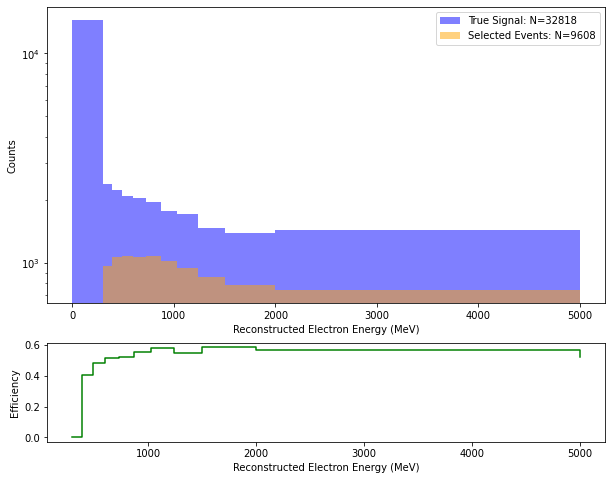

In [331]:
bins = [0, 300, 390, 490, 600, 730, 870, 1030, 1240, 1500, 2000, 5000]

eff, selected_hist = get_efficiency(ele_ele_e, ele_e_sel, bins, (bins[0], bins[-1]), "Reconstructed Electron Energy (MeV)", logy=True)


In [332]:
theta_ee = 0.2

In [333]:
x_mb23_mod = np.insert(x_mb23, 0, x_mb23[0])
y_mb23_mod = np.insert(y_mb23, 0, y_mb23[0]+300)

x_mb23_mod = 1.2 * x_mb23_mod #pad by 30%

In [334]:
# lsnd_grid = make_grid(mu_ele_e, ele_ele_e, true_nue_e, true_numu_e, L, theta_ee, bins, (bins[0], bins[-1]))
lsnd_grid = make_grid(mu_ele_e, ele_ele_e, true_numu_e, true_nue_e, L, bins, (bins[0], bins[-1]), limit_curves[-3:], theta_ee=theta_ee, left_of=dataCurves(x_mb23_mod, y_mb23_mod, 'red', '-', 'line', 'MicroBooNE Result (2023)'))


  lsnd_low: 81 points selected from 30x30 candidates
  lsnd_mid: 5 points selected from 10x10 candidates
  lsnd_upper: 41 points selected from 15x15 candidates


Plotting for fixed theta_ee = 0.2


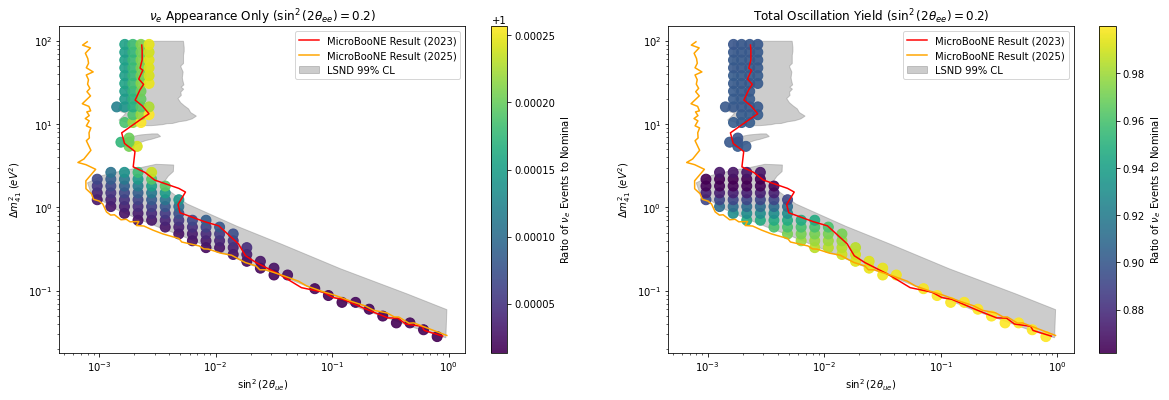

In [335]:
plot_phase_space(lsnd_grid, eff, selected_hist, limit_curves, err_sensitivity=False)

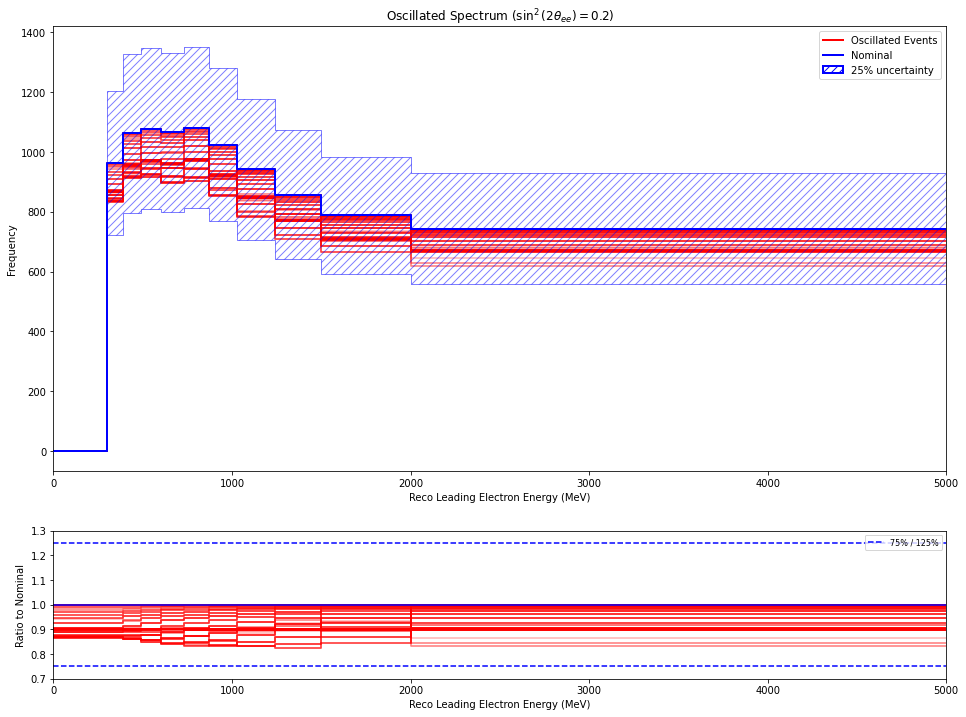

In [336]:
fig = plot_variable_osc(lsnd_grid, eff, selected_hist ,'Reco Leading Electron Energy (MeV)', uncertainty=0.25)


In [315]:
def leftmost_x_at_y(x_curve, y_curve, y_query):
    """For each y in y_query, scan all curve segments and return the minimum x crossing."""
    x_out = np.full(len(y_query), np.inf)
    for i in range(len(y_curve) - 1):
        y0, y1 = y_curve[i], y_curve[i + 1]
        x0, x1 = x_curve[i], x_curve[i + 1]
        if y0 == y1:
            continue
        y_lo, y_hi = min(y0, y1), max(y0, y1)
        mask = (y_query >= y_lo) & (y_query <= y_hi)
        if not np.any(mask):
            continue
        t = (y_query[mask] - y0) / (y1 - y0)
        x_at_y = x0 + t * (x1 - x0)
        x_out[mask] = np.minimum(x_out[mask], x_at_y)
    return x_out

y_common = np.logspace(np.log10(min(y_prospect.min(), y_katrin12.min())),
                       np.log10(max(y_prospect.max(), y_katrin12.max())), 2000)

x_p        = leftmost_x_at_y(x_prospect,  y_prospect,  y_common)
x_k        = leftmost_x_at_y(x_katrin12, y_katrin12, y_common)
x_combined = np.minimum(x_p, x_k)

x_combined = x_combined * 1.2 # pad by 20%

In [316]:
grid = make_grid(mu_ele_e, ele_ele_e, true_numu_e, true_nue_e, L, bins, (bins[0], bins[-1]), limit_curves_e[-2:], theta_mue=0.002, left_of=dataCurves(x_combined, y_common, 'magenta', '-', 'line', 'PROSPECT 5$\\sigma$ CL'))

  sg_low: 9 points selected from 10x10 candidates
  sg_high: 43 points selected from 20x20 candidates


Plotting for fixed theta_ue = 0.002


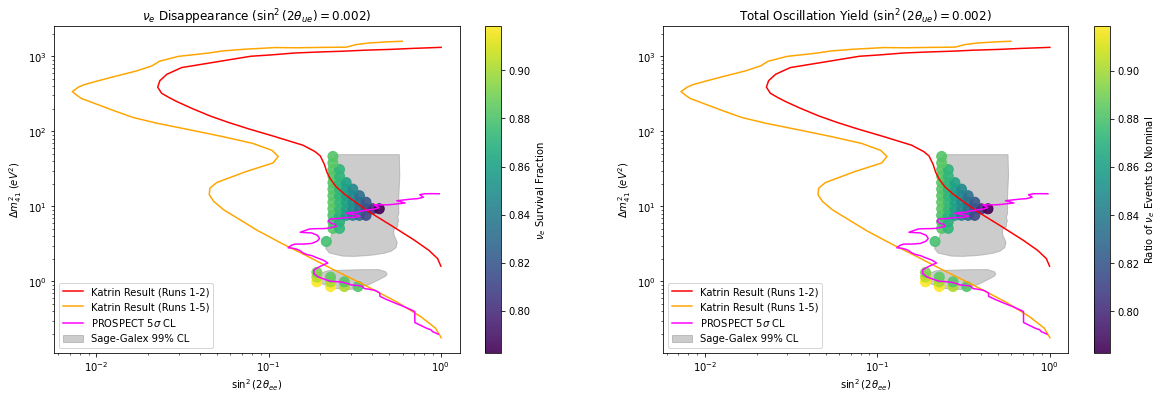

In [317]:
plot_phase_space(grid, eff, selected_hist, limit_curves_e, err_sensitivity=False)

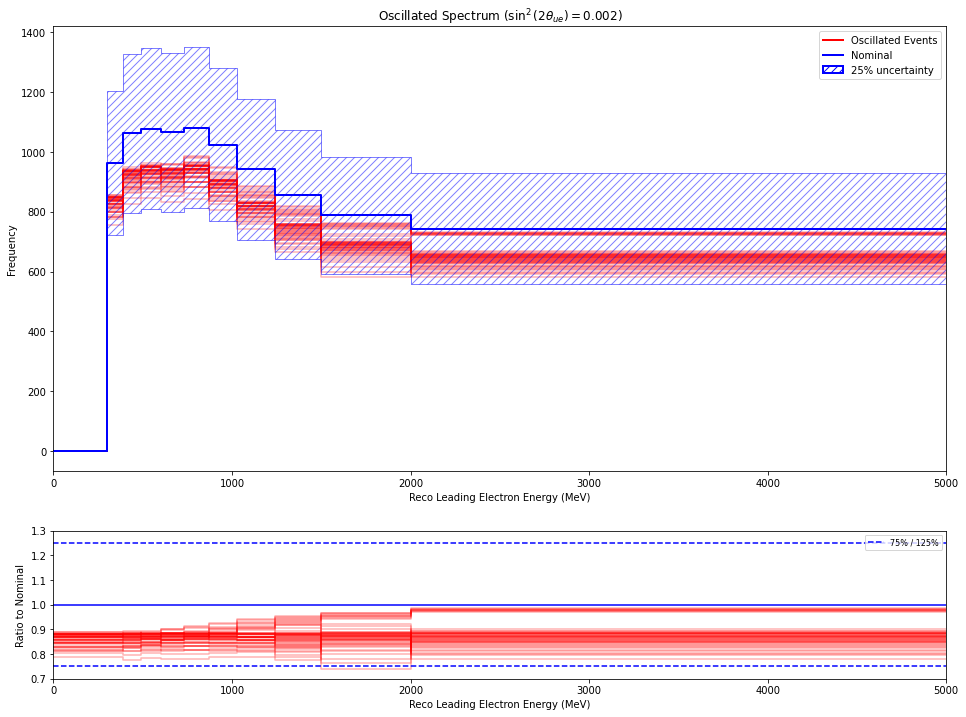

In [318]:
fig = plot_variable_osc(grid, eff, selected_hist ,'Reco Leading Electron Energy (MeV)', uncertainty=0.25)


Total events in range (-1.0, 1.0): 32856/39164
Selected events in range (-1.0, 1.0): 9637/9637


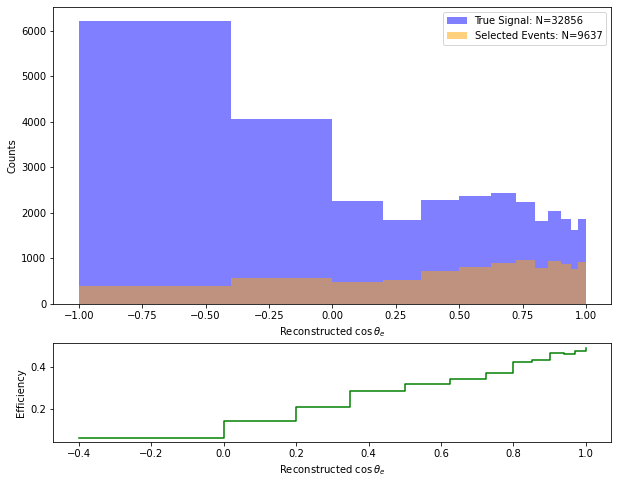

In [337]:
bins = [-1.0, -0.4, 0.0, 0.2, 0.35, 0.5, 0.625, 0.725, 0.8, 0.85, 0.9, 0.94, 0.97, 1.0]

eff, selected_hist = get_efficiency(ele_ele_cos, ele_cos_sel, bins, (bins[0], bins[-1]), r"Reconstructed $\cos\theta_{e}$", logy=False)

In [338]:
lsnd_grid = make_grid(mu_ele_cos, ele_ele_cos, true_numu_e, true_nue_e, L, bins, (bins[0], bins[-1]), limit_curves[-3:], theta_ee=theta_ee, left_of=dataCurves(x_mb23_mod, y_mb23_mod, 'red', '-', 'line', 'MicroBooNE Result (2023)'))

  lsnd_low: 81 points selected from 30x30 candidates


  lsnd_mid: 5 points selected from 10x10 candidates
  lsnd_upper: 41 points selected from 15x15 candidates


Plotting for fixed theta_ee = 0.2


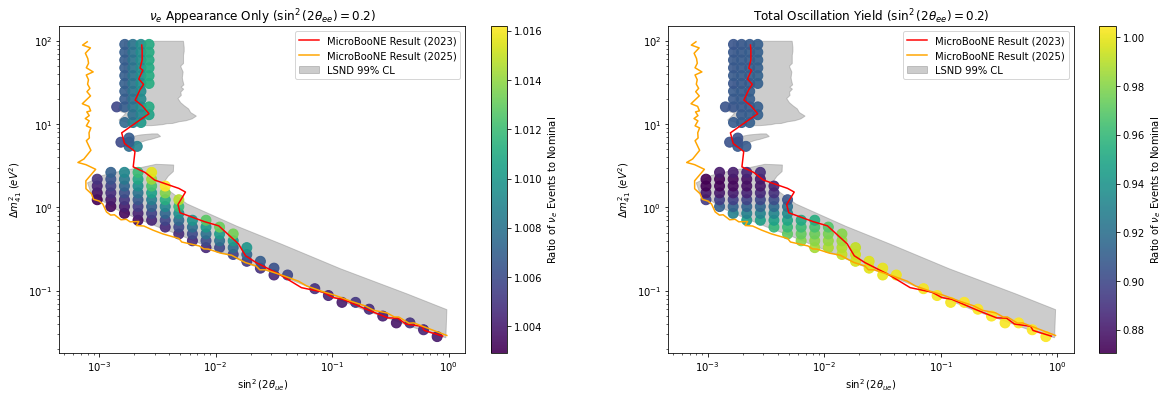

In [339]:
plot_phase_space(lsnd_grid, eff, selected_hist, limit_curves, err_sensitivity=False)

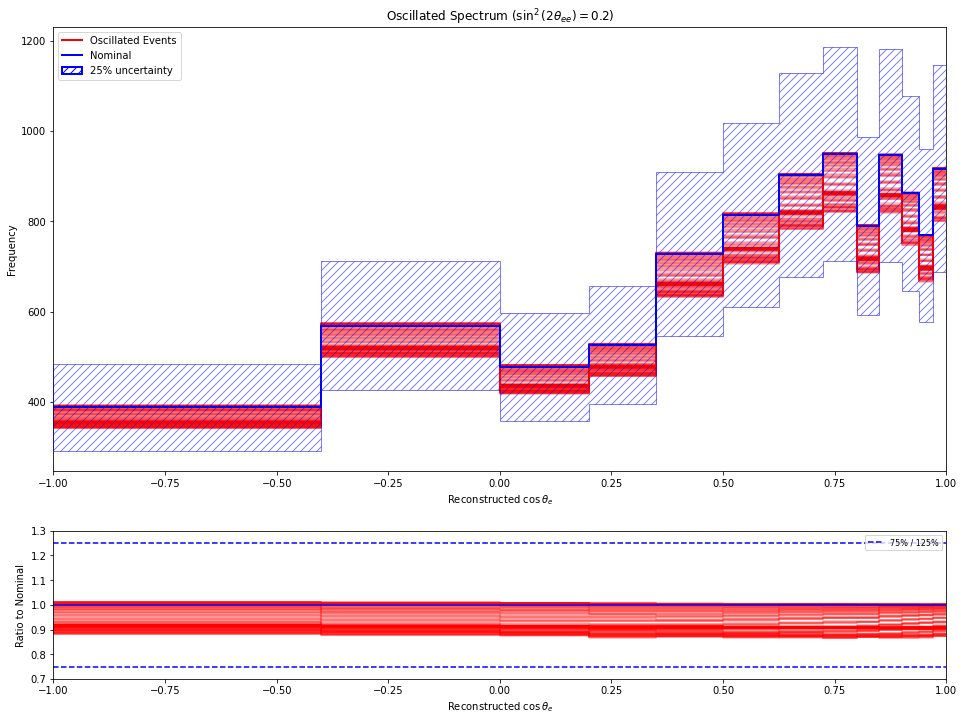

In [340]:
fig = plot_variable_osc(lsnd_grid, eff, selected_hist ,r'Reconstructed $\cos\theta_{e}$', uncertainty=0.25)


In [341]:
grid = make_grid(mu_ele_cos, ele_ele_cos, true_numu_e, true_nue_e, L, bins, (bins[0], bins[-1]), limit_curves_e[-2:], theta_mue=0.002, left_of=dataCurves(x_combined, y_common, 'magenta', '-', 'line', 'PROSPECT 5$\\sigma$ CL'))


  sg_low: 9 points selected from 10x10 candidates
  sg_high: 43 points selected from 20x20 candidates


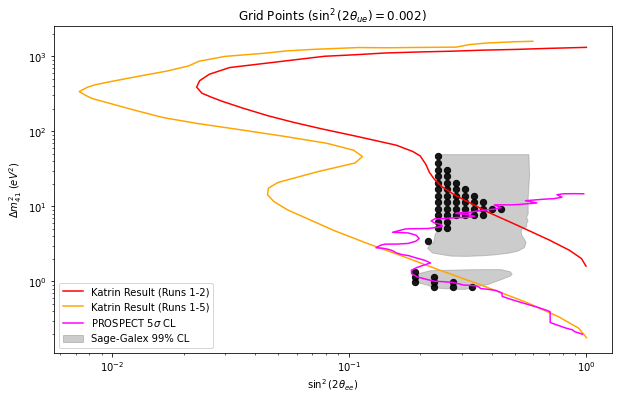

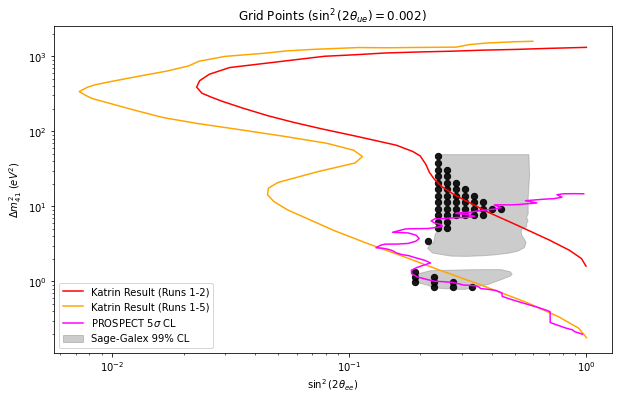

In [344]:
plot_phase_space(grid, eff, selected_hist, limit_curves_e, err_sensitivity=False, points_only=True)

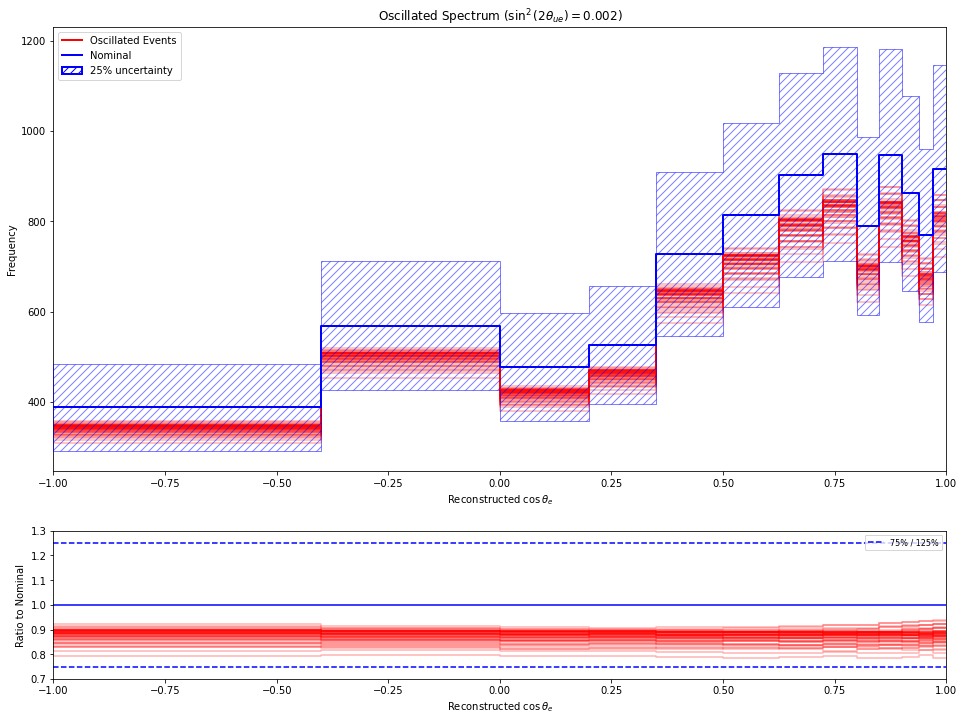

In [325]:
fig = plot_variable_osc(grid, eff, selected_hist ,r'Reconstructed $\cos\theta_{e}$', uncertainty=0.25)
